# EVA02 - Diagnóstico y Análisis Predictivo sobre Mediciones Eléctricas
**Asignatura:** Minería de Datos  
**Objetivo:** Desarrollar un proceso completo de Ciencia de Datos para diagnosticar la salud de 24 inversores en una planta solar fotovoltaica, modelar la conversión DC-AC y pronosticar la generación agregada de energía.
---

## Fase 1: Comprensión del Problema

### Contexto
El dataset `2107_electrical_data.csv` contiene **632,952 registros** a frecuencia de **5 minutos** desde noviembre 2017 hasta noviembre 2023, con 120 variables de 24 inversores.

### Preguntas de Negocio:
1. **Diagnóstico no supervisado:** ¿Podemos clasificar automáticamente los 24 inversores según su eficiencia operativa?
2. **Modelo supervisado:** ¿Qué tan bien podemos modelar la potencia AC a partir de variables DC?
3. **Forecasting:** ¿Es posible predecir la generación total de la planta a 24h vista?

### Objetivo del paso
Importar librerías y configurar el entorno de análisis.
### Concepto clave
pandas/numpy para manipulación de datos; matplotlib/seaborn para visualización; los módulos src/ encapsulan la lógica de carga, preprocesamiento y modelado.
### Código
(Ejecutar la celda siguiente)
### Qué observar en la salida
Confirmación de que todas las importaciones se resolvieron sin errores.


In [17]:
# Configurar librerías y ambiente de análisis
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Agregar el directorio raíz del proyecto al path para importar módulos personalizados
sys.path.append(os.path.abspath('..'))

from src.data_loader import load_data
from src.preprocessing import clean_and_impute, feature_engineering, filter_daylight, get_inverter_cols
from src.clustering import extract_inverter_features, run_kmeans_analysis, perform_final_clustering
from src.regression import prepare_regression_data, train_and_compare_regressors
from src.forecasting import prepare_forecasting_data, run_forecasting_analysis

# Configuración de estilo para gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Configuracion de librerias completada.')

Configuracion de librerias completada.


## Fase 2: Exploración de Datos (EDA)

### Objetivo del paso
Cargar el dataset completo desde el archivo CSV.
### Concepto clave
La función `load_data()` optimiza memoria usando `float32` en lugar de `float64`, reduciendo el consumo de RAM a la mitad (~400 MB vs ~800 MB).
### Código
(Ejecutar la celda siguiente)
### Qué observar en la salida
Shape (632952, 120), rango temporal nov-2017 a nov-2023, primeras 3 filas.
### Errores típicos
- Usar `dtype=float64` por defecto duplica innecesariamente el uso de memoria.
- No verificar que el índice temporal sea `datetime64` impide el remuestreo.


In [18]:
# Cargar dataset eléctrico completo (632k registros, 120 variables)
csv_path = '../2107_electrical_data.csv'
df_raw = load_data(csv_path)
print(f'Shape: {df_raw.shape}')
print(f'Rango temporal: {df_raw.index.min()} a {df_raw.index.max()}')
print(f'Columnas:\n{list(df_raw.columns[:10])}...')
df_raw.head(3)

Cargando datos desde 2107_electrical_data.csv...
Cargadas 632,952 filas y 119 columnas en 3.70 segundos.
Uso de memoria del DataFrame: 292.16 MB
Shape: (632952, 119)
Rango temporal: 2017-11-01 00:00:00 a 2023-11-07 23:55:00
Columnas:
['inv_01_dc_current_inv_149579', 'inv_01_dc_voltage_inv_149580', 'inv_01_ac_current_inv_149581', 'inv_01_ac_voltage_inv_149582', 'inv_01_ac_power_inv_149583', 'inv_02_dc_current_inv_149584', 'inv_02_dc_voltage_inv_149585', 'inv_02_ac_current_inv_149586', 'inv_02_ac_voltage_inv_149587', 'inv_02_ac_power_inv_149588']...


,inv_01_dc_current_inv_149579,inv_01_dc_voltage_inv_149580,inv_01_ac_current_inv_149581,inv_01_ac_voltage_inv_149582,inv_01_ac_power_inv_149583,inv_02_dc_current_inv_149584,inv_02_dc_voltage_inv_149585,inv_02_ac_current_inv_149586,inv_02_ac_voltage_inv_149587,inv_02_ac_power_inv_149588,...,inv_23_dc_current_inv_149689,inv_23_dc_voltage_inv_149690,inv_23_ac_current_inv_149691,inv_23_ac_voltage_inv_149692,inv_23_ac_power_inv_149693,inv_24_dc_current_inv_149694,inv_24_dc_voltage_inv_149695,inv_24_ac_current_inv_149696,inv_24_ac_voltage_inv_149697,inv_24_ac_power_inv_149698
measured_on,,,,,,,,,,,,,,,,,,,,,
2017-11-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-11-01 00:05:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-11-01 00:10:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Objetivo del paso
Visualizar el perfil diario de generación eléctrica.
### Concepto clave
Campana solar: la generación fotovoltaica sigue la irradiancia solar, formando una curva que sube al amanecer, alcanza su pico al mediodía y baja al atardecer.
### Código
(Ejecutar la celda siguiente)
### Qué observar en la salida
Ambos inversores muestran perfil de campana. Pico de generación al mediodía. Generación cero en noche.
### Errores típicos
- Graficar demasiados días sin diferenciarlos (líneas superpuestas).
- Olvidar filtrar horas nocturnas para análisis estadísticos posteriores.


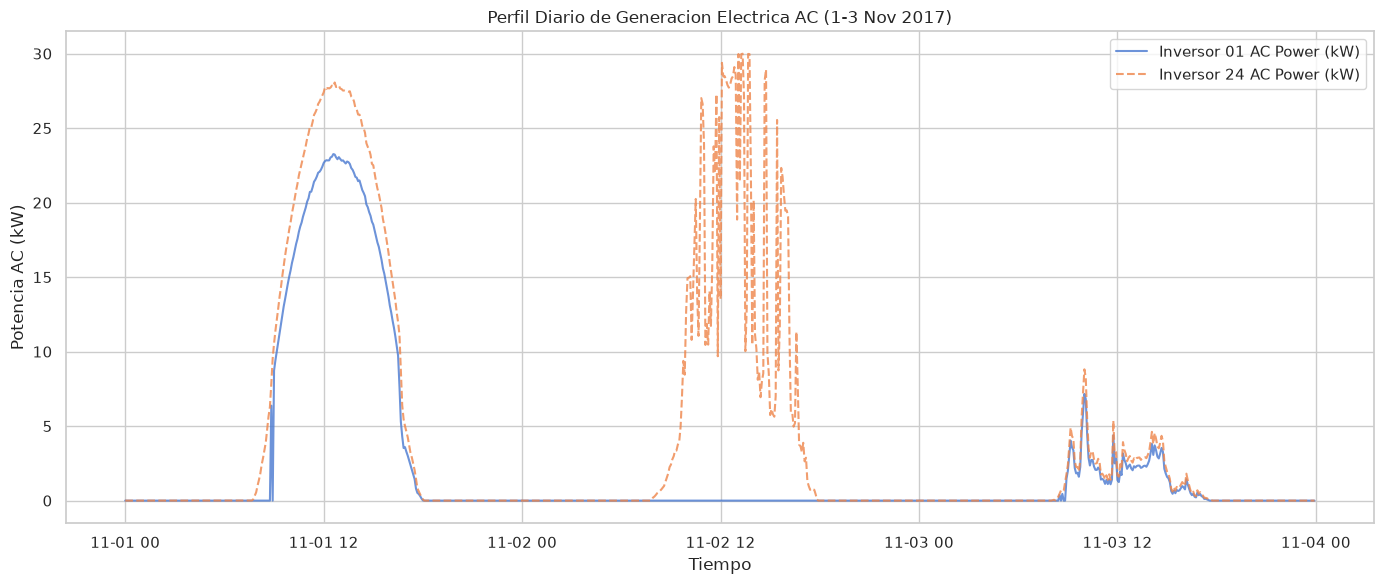

In [19]:
# Graficar perfil diario de generación: ciclo solar día/noche
df_sample_days = df_raw.loc['2017-11-01':'2017-11-03']

plt.figure(figsize=(14, 6))
plt.plot(df_sample_days.index, df_sample_days['inv_01_ac_power_inv_149583'], label='Inversor 01 AC Power (kW)', alpha=0.8)
plt.plot(df_sample_days.index, df_sample_days['inv_24_ac_power_inv_149698'], label='Inversor 24 AC Power (kW)', alpha=0.8, linestyle='--')

plt.title('Perfil Diario de Generacion Electrica AC (1-3 Nov 2017)')
plt.xlabel('Tiempo')
plt.ylabel('Potencia AC (kW)')
plt.legend()
plt.tight_layout()
plt.savefig('../output/plots/01_eda_campana_solar.png', dpi=150)
plt.show()

### Objetivo del paso
Comparar la distribución de potencia AC generada por cada inversor.
### Concepto clave
Boxplot: muestra mediana, cuartiles (Q1, Q3) y valores atípicos. Útil para detectar inversores con rendimiento anómalo.
### Código
(Ejecutar la celda siguiente)
### Qué observar en la salida
La mayoría de inversores tienen medianas ~30-40 kW. Inversores 06, 19 muestran distribuciones más bajas.
### Errores típicos
- Incluir horas nocturnas (potencia=0) sesga la distribución hacia abajo.
- Confundir valores atípicos con fallas de sensor (un sensor dañado no es un outlier estadístico).


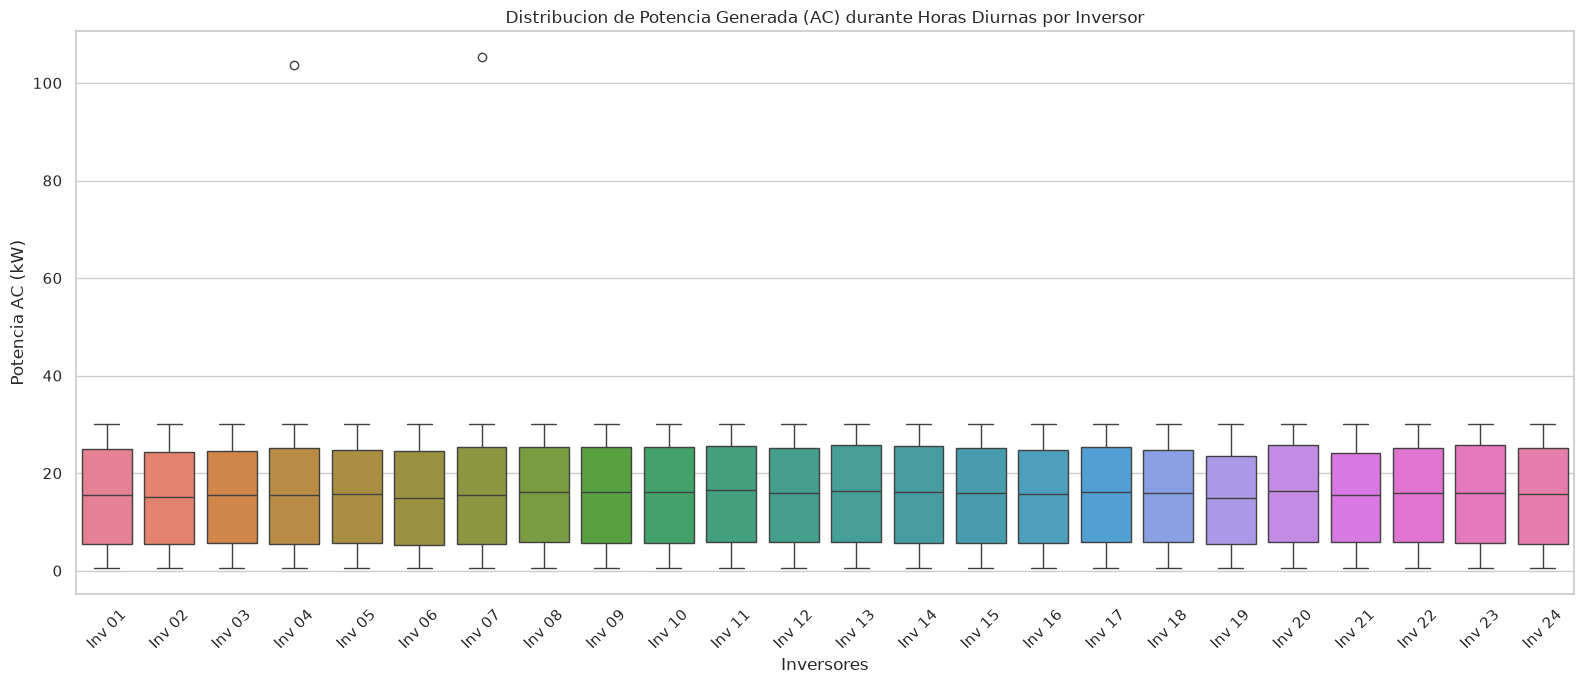

In [4]:
# Distribución de potencia AC por inversor en horas diurnas
ac_cols = []
for i in range(1, 25):
    cols = get_inverter_cols(df_raw, i)
    ac_cols.append(cols['ac_power'])

df_diurnal_ac = df_raw[ac_cols][df_raw[ac_cols] > 0.5]

plt.figure(figsize=(16, 7))
sns.boxplot(data=df_diurnal_ac)
plt.xticks(range(24), [f'Inv {i:02d}' for i in range(1, 25)], rotation=45)
plt.title('Distribucion de Potencia Generada (AC) durante Horas Diurnas por Inversor')
plt.ylabel('Potencia AC (kW)')
plt.xlabel('Inversores')
plt.tight_layout()
plt.savefig('../output/plots/02_eda_boxplot_potencia_ac.png', dpi=150)
plt.show()

### Objetivo del paso
Analizar la relación lineal entre las variables eléctricas de un inversor típico (Inv01).
### Concepto clave
Matriz de correlación de Pearson: mide la relación lineal entre pares de variables (rango -1 a 1). Valores > 0.9 indican alta colinealidad.
### Código
(Ejecutar la celda siguiente)
### Qué observar en la salida
Correlaciones > 0.99 entre corriente DC, corriente AC y potencia AC. Esto justifica usar regresión lineal para modelar potencia AC. Nota: usamos Inv01 como ejemplo; todos los inversores muestran la misma relación física.
### Errores típicos
- La correlación no implica causalidad (ej. corriente y voltaje pueden covariar sin relación causal directa).
- Confundir correlación lineal (Pearson) con dependencia no lineal.


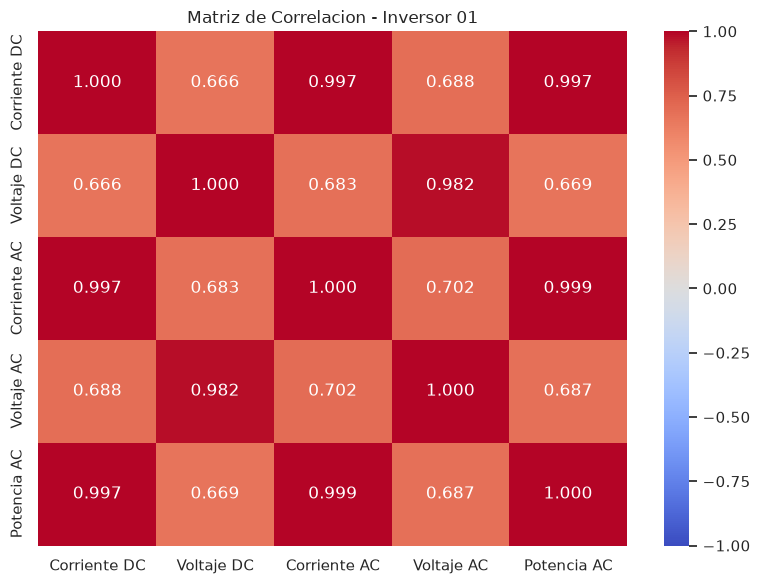

In [5]:
# Matriz de correlación: relación lineal entre variables DC-AC
inv_01_cols = get_inverter_cols(df_raw, 1)
df_corr = df_raw[[
    inv_01_cols['dc_current'], inv_01_cols['dc_voltage'],
    inv_01_cols['ac_current'], inv_01_cols['ac_voltage'],
    inv_01_cols['ac_power']
]].copy()
df_corr.columns = ['Corriente DC', 'Voltaje DC', 'Corriente AC', 'Voltaje AC', 'Potencia AC']

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.3f', vmin=-1, vmax=1)
plt.title('Matriz de Correlacion - Inversor 01')
plt.tight_layout()
plt.savefig('../output/plots/03_eda_correlaciones.png', dpi=150)
plt.show()

## Fase 3: Preparación de Datos
- Corrección de nombres (Inversor 15)
- Imputación de voltaje DC faltante (Inversor 05)
- Ingeniería de características (DC Power, Eficiencia)
- Filtrado diurno para diagnóstico

### Objetivo del paso
Limpiar, imputar valores faltantes y crear nuevas características.
### Concepto clave
Imputación: estimación de valores faltantes usando datos vecinos (ffill/bfill).

**Caso Inv05:** Es el único inversor que **no tiene columna de voltaje DC** — el sensor físico nunca fue instalado o no reporta la variable. Mientras los otros 23 inversores tienen 5 sensores (dc_current, dc_voltage, ac_current, ac_voltage, ac_power), Inv05 solo tiene 4. Sin esta columna no podemos calcular DC Power = I × V ni la eficiencia de conversión.

**Solución:** Se imputa el voltaje DC como el **promedio de los otros 23 inversores** en cada timestamp. Esto funciona porque en una planta solar todos los paneles reciben la misma irradiancia → el voltaje DC es similar entre inversores en un mismo instante. Esto evita descartar ~300k registros del Inv05.

Ingeniería de características: crear DC Power (I×V) y eficiencia (AC/DC) revela relaciones no obvias en datos crudos.
### Código
(Ejecutar la celda siguiente)
### Qué observar en la salida
0 duplicados. La celda imprime "Nulos en Inversor 05 post-imputacion" para verificar que la columna imputada no tenga NaN. Eficiencias diurnas > 90% son normales.
### Errores típicos
- Imputar sin verificar primero el patrón de nulos (MCAR, MAR, MNAR).
- Usar la media global cuando los datos son temporales (introducir sesgo futuro).


In [6]:
# Limpiar, imputar valores nulos y crear características derivadas
num_duplicates = df_raw.index.duplicated().sum()
print(f'Estampas de tiempo duplicadas: {num_duplicates}')
df_cleaned_temp = df_raw[~df_raw.index.duplicated(keep='first')] if num_duplicates > 0 else df_raw

df_clean = clean_and_impute(df_cleaned_temp)

inv_05_cols = [c for c in df_clean.columns if 'inv_05_' in c]
print('\nNulos en Inversor 05 post-imputacion:')
print(df_clean[inv_05_cols].isnull().sum())

df_feat = feature_engineering(df_clean)

df_daylight = filter_daylight(df_feat)

eff_cols = [f'inv_{i:02d}_efficiency' for i in range(1, 6)]
print('\nEjemplo de eficiencias diurnas:')
print(df_daylight[eff_cols].head(3))

Estampas de tiempo duplicadas: 0
Iniciando limpieza e imputación de datos...
Columna renombrada: inv_15_ac_power_iinv_149653 -> inv_15_ac_power_inv_149653
Imputadas 183372 celdas con valores nulos via ffill/bfill.
Imputado voltaje DC faltante del Inversor 05 como promedio de los otros 23 inversores.
Limpieza completada. Valores nulos restantes: 0

Nulos en Inversor 05 post-imputacion:
inv_05_dc_current_inv_149599    0
inv_05_ac_current_inv_149601    0
inv_05_ac_voltage_inv_149602    0
inv_05_ac_power_inv_149603      0
inv_05_dc_voltage_inv_149600    0
dtype: int64
Realizando ingeniería de características...
Ingeniería de características completada.
Filtrado a horas diurnas: 295,541 filas (de 632,952 originales).

Ejemplo de eficiencias diurnas:
                     inv_01_efficiency  inv_02_efficiency  inv_03_efficiency  \
measured_on                                                                    
2017-11-01 07:50:00                0.0          53.716820          60.821957   
2017-

### Fundamento Matemático de los Algoritmos Seleccionados

Basado en el EDA (relación lineal DC-AC, fuerte estacionalidad diaria en la generación, 3 grupos naturales de eficiencia), seleccionamos los siguientes algoritmos con su fundamento teórico:

**K-Means (Aprendizaje No Supervisado):**

Minimiza la suma de distancias al cuadrado entre cada punto y el centroide de su cluster:

$$J = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2$$

Donde $\mu_i$ es el centroide (promedio) del cluster $i$. El algoritmo itera: (1) asignar cada punto al centroide más cercano, (2) recalcular centroides como el promedio de los puntos asignados. La inercia $J$ siempre decrece, garantizando convergencia.

**Gradient Boosting (Aprendizaje Supervisado):**

Construye árboles de decisión secuencialmente, donde cada nuevo árbol corrige los residuos (errores) del conjunto anterior:

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

Donde $h_m$ es un árbol que predice el error actual $y - F_{m-1}(x)$, y $\eta$ (learning rate) controla la contribución de cada paso. Es robusto a overfitting cuando se limita la profundidad de los árboles.

**Regresión Lineal (Supervisado):**

Asume una relación lineal entre predictores y target: $y = \beta_0 + \beta_1 x_1 + ... + \beta_n x_n + \epsilon$. Los coeficientes $\beta$ se estiman minimizando la suma de errores al cuadrado (MCO).

**Persistencia (Baseline para Forecasting):**

El valor predicho para el tiempo $t$ es el valor observado 24 horas antes: $\hat{y}_t = y_{t-24}$. Sirve como referencia mínima que cualquier modelo debe superar.


## Fase 4a: Aprendizaje No Supervisado - Diagnóstico de Inversores (K-Means)

**Concepto clave:** K-Means agrupa datos en K clusters minimizando la distancia intra-cluster. Usamos mediana de eficiencia, volatilidad y tasa de inactividad.

**Nota importante:** Hasta aquí no sabemos qué inversor es "el mejor". El clustering a continuación revelará la respuesta. Esto evita sesgo de selección: elegimos el modelo supervisado basado en evidencia, no por inspección previa.


### Objetivo del paso
Extraer características representativas de cada inversor para clustering.
### Concepto clave
Feature Engineering para no supervisado: reducimos 6 años de series temporales a 3 métricas por inversor (eficiencia mediana, volatilidad, tasa de inactividad).
### Código
(Ejecutar la celda siguiente)
### Qué observar en la salida
DataFrame 24 filas × 4 columnas: cada fila es un inversor.
### Errores típicos
- Usar promedios simples cuando la distribución no es simétrica (preferir mediana).
- No escalar las features antes de K-Means (variables con escalas grandes dominan).


In [7]:
# Extraer features operativas de cada inversor (eficiencia, volatilidad, inactividad)
df_inv = extract_inverter_features(df_daylight)
df_inv.head(24)

Extrayendo características por inversor para clustering...
Características extraídas para 24 inversores.


,inverter_id,median_efficiency,mean_efficiency,std_efficiency,outage_rate,max_ac_power
0,1,96.632179,84.123413,27.356398,0.000007,30.096001
1,2,97.138138,83.219437,30.900473,0.000008,30.087999
2,3,97.496590,90.149422,20.825020,0.000015,30.091999
3,4,97.531723,85.126770,30.380882,0.000008,103.709999
4,5,97.171150,88.554398,24.491402,0.000000,30.084999
5,6,97.088394,80.973389,32.667206,0.000008,30.086000
6,7,97.955215,81.318413,34.459843,0.000008,105.341003
7,8,96.692932,87.755692,24.082483,0.000011,30.089001
8,9,97.929070,92.434830,17.389421,0.000007,30.089001
9,10,98.090378,90.351036,22.350121,0.000004,30.087999


### Objetivo del paso
Determinar el número óptimo de clusters K usando el método del codo y silueta.
### Concepto clave
Codo: punto donde la inercia deja de decrecer abruptamente. Silueta: mide qué tan similares son los puntos dentro de un cluster vs otros clusters (rango -1 a 1). Valores > 0.3 indican estructura cluster aceptable.
### Código
(Ejecutar la celda siguiente)
### Qué observar en la salida
K=3 como punto de inflexión (inercia) con silueta ~0.34.
### Errores típicos
- Elegir K solo por el codo ignorando la silueta (puede sugerir K con clusters no cohesivos).
- Asumir que K=3 es la respuesta correcta sin validar con el contexto del negocio.


Ejecutando búsqueda de parámetros K-Means (Codo & Silueta)...


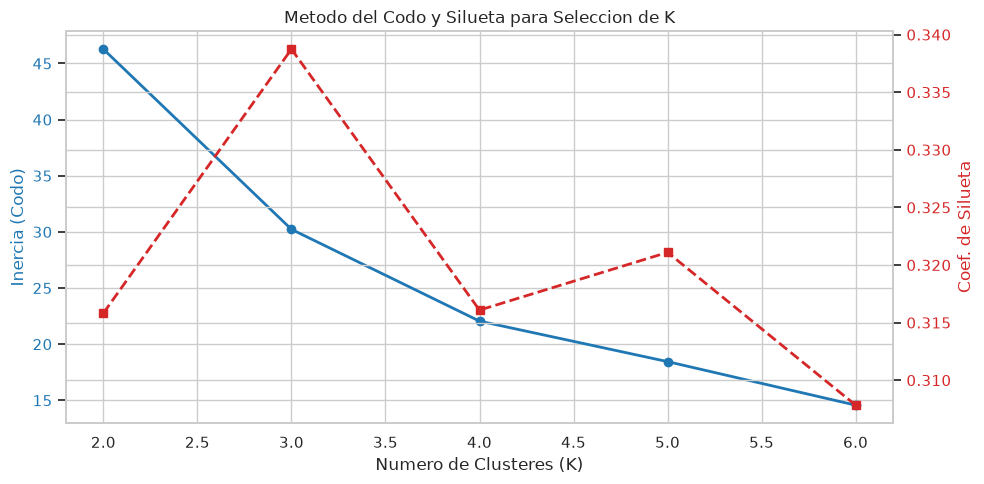

K = 2 -> Inercia: 46.28 | Silueta: 0.3158
K = 3 -> Inercia: 30.23 | Silueta: 0.3387
K = 4 -> Inercia: 22.05 | Silueta: 0.3161
K = 5 -> Inercia: 18.45 | Silueta: 0.3211
K = 6 -> Inercia: 14.57 | Silueta: 0.3078


In [8]:
# K-Means: determinar K óptimo con método del codo + coeficiente de silueta
k_res, X_scaled = run_kmeans_analysis(df_inv, max_k=6)

fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:blue'
ax1.set_xlabel('Numero de Clusteres (K)')
ax1.set_ylabel('Inercia (Codo)', color=color)
ax1.plot(k_res['k_values'], k_res['inertia'], marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Coef. de Silueta', color=color)
ax2.plot(k_res['k_values'], k_res['silhouette'], marker='s', color=color, linestyle='--', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Metodo del Codo y Silueta para Seleccion de K')
fig.tight_layout()
plt.show()

for k, inertia, sil in zip(k_res['k_values'], k_res['inertia'], k_res['silhouette']):
    print(f'K = {k} -> Inercia: {inertia:,.2f} | Silueta: {sil:.4f}')

### Objetivo del paso
Asignar los clusters finales con K=3 y etiquetar cada inversor por salud.
### Concepto clave
Una vez fijado K, se ejecuta K-Means con random_state fijo para reproducibilidad. Las etiquetas se asignan a grupos semánticos según la eficiencia mediana.
### Código
(Ejecutar la celda siguiente)
### Qué observar en la salida
Inversores 9-22 (alta eficiencia) etiquetados como "Óptimo". Inversores 1-8 (baja eficiencia) como "Crítico".
### Errores típicos
- Las etiquetas de cluster (0,1,2) son arbitrarias; deben mapearse a significado de negocio.
- Inicializar K-Means con diferentes semillas puede dar clusters distintos.


In [9]:
# Asignar clusters de salud con K=3 y etiquetar cada inversor
df_clustering = perform_final_clustering(df_inv, X_scaled, n_clusters=3)
df_clustering.sort_values(by='median_efficiency', ascending=False)

Ajustando K-Means final con K=3...
Resultados de clustering guardados en ../output/tables/inverter_health_clustering.csv


,inverter_id,median_efficiency,mean_efficiency,std_efficiency,outage_rate,max_ac_power,cluster,health_status
21,22,98.331367,94.662064,13.800942,0.000004,30.093000,1,Óptimo (Saludable)
13,14,98.328072,90.787483,22.423388,0.000011,30.091000,1,Óptimo (Saludable)
9,10,98.090378,90.351036,22.350121,0.000004,30.087999,1,Óptimo (Saludable)
6,7,97.955215,81.318413,34.459843,0.000008,105.341003,0,Crítico (Sensor/Falla)
11,12,97.939789,93.181038,15.353867,0.000007,30.089001,1,Óptimo (Saludable)
23,24,97.935562,87.595078,27.266382,0.000000,30.089001,0,Crítico (Sensor/Falla)
8,9,97.929070,92.434830,17.389421,0.000007,30.089001,1,Óptimo (Saludable)
10,11,97.807838,93.844902,13.915988,0.000007,30.089001,1,Óptimo (Saludable)
14,15,97.697922,91.630608,18.389185,0.000007,30.086000,1,Óptimo (Saludable)
17,18,97.650055,92.075104,17.181637,0.000025,30.086000,2,Sub-óptimo (Pérdidas/Estrés)


### Objetivo del paso
Visualizar los clusters de salud en un plano de eficiencia vs volatilidad.
### Concepto clave
Scatter plot 2D: cada punto es un inversor, coloreado por cluster. Inversores saludables: alta eficiencia y baja volatilidad (esquina inferior derecha).
### Código
(Ejecutar la celda siguiente)
### Qué observar en la salida
Tres grupos claramente separados. Inv22 destaca como el más saludable (eficiencia ≥ 98.3%, baja volatilidad).
### Errores típicos
- Usar colores ambiguos o no incluir etiquetas de inversor (dificulta identificar cada uno).
- No revisar los centroides para interpretar los clusters.


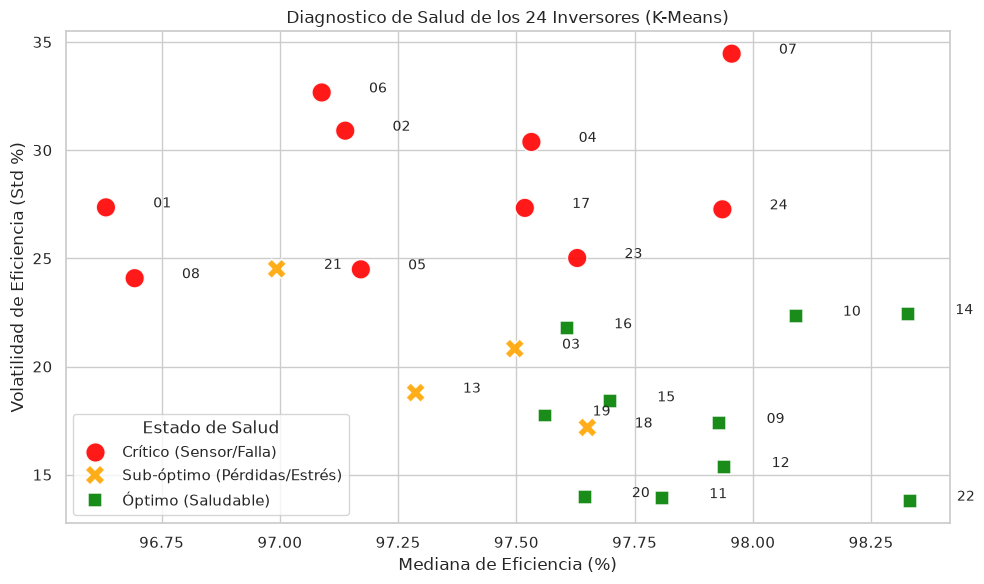

In [10]:
# Visualizar clusters de salud de inversores (eficiencia vs volatilidad)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clustering,
    x='median_efficiency',
    y='std_efficiency',
    hue='health_status',
    palette={'Optimo (Saludable)': 'green', 'Sub-optimo (Perdidas/Estres)': 'orange', 'Critico (Sensor/Falla)': 'red', 'Óptimo (Saludable)': 'green', 'Sub-óptimo (Pérdidas/Estrés)': 'orange', 'Crítico (Sensor/Falla)': 'red'},
    style='health_status',
    s=200,
    alpha=0.9
)

for idx, row in df_clustering.iterrows():
    plt.text(row['median_efficiency'] + 0.1, row['std_efficiency'], f"{int(row['inverter_id']):02d}", fontsize=10)

plt.title('Diagnostico de Salud de los 24 Inversores (K-Means)')
plt.xlabel('Mediana de Eficiencia (%)')
plt.ylabel('Volatilidad de Eficiencia (Std %)')
plt.legend(title='Estado de Salud')
plt.tight_layout()
plt.show()

## Fase 4b: Aprendizaje Supervisado - Regresión de Potencia AC

**Concepto clave:** Modelamos la conversión DC-AC del Inversor 22 (saludable). Comparamos Regresión Lineal vs Random Forest vs XGBoost.

### Objetivo del paso
Preparar las variables predictoras DC y la variable objetivo AC para el modelo supervisado.
### Concepto clave
Según el clustering de la Fase 4a, el Inversor 22 resultó ser el más saludable: mayor eficiencia mediana (98.33%) y menor volatilidad. Ahora modelamos su conversión DC→AC. Features: corriente DC, voltaje DC, corriente AC, voltaje AC. Target: potencia AC. Se filtran solo horas activas (DC current > 0.5A).
### Código
(Ejecutar la celda siguiente)
### Qué observar en la salida
Dimensiones ~295k filas × 4 features. Todas las variables son numéricas continuas.
### Errores típicos
- Incluir horas nocturnas (DC current ≈ 0) introduce ruido en la regresión.
- No verificar multicolinealidad entre predictores (alto R² ajustado puede engañar).


In [11]:
# Preparar features DC y target AC para regresión (Inv22 elegido por clustering, Fase 4a)
X_reg, y_reg = prepare_regression_data(df_clean, inv_id=22)
print(f'Dimensiones de entrada: {X_reg.shape}')
X_reg.head(3)

Dimensiones de entrada: (288745, 4)


,dc_current,dc_voltage,ac_current,ac_voltage
measured_on,,,,
2017-11-01 07:50:00,0.635,644.749023,0.000,276.825012
2017-11-01 07:55:00,1.043,690.927002,0.820,276.417999
2017-11-01 08:00:00,1.547,710.801025,1.253,276.812012


### Objetivo del paso
Entrenar y comparar 3 modelos de regresión con validación y ajuste de hiperparámetros.
### Concepto clave
Train/Test split 80/20 para evaluar generalización. RandomizedSearchCV busca la mejor combinación de hiperparámetros mediante validación cruzada. Se comparan: Regresión Lineal (línea recta), Random Forest (promedio de árboles), XGBoost (árboles secuenciales con regularización L1/L2).
### Código
(Ejecutar la celda siguiente)
### Qué observar en la salida
Los 3 modelos logran R² > 0.997. XGBoost tuneado es el mejor (R² > 0.9996, MAE ~0.09 kW). Los mejores hiperparámetros se muestran en pantalla.
### Errores típicos
- No escalar features cuando se usa Regresión Lineal (coeficientes no comparables).
- Buscar hiperparámetros en todo el dataset sin separar test (data leakage).


In [12]:
# Entrenar 3 modelos de regresión con búsqueda de hiperparámetros RandomizedSearchCV
df_reg_metrics, X_test, y_test, reg_preds = train_and_compare_regressors(X_reg, y_reg)
df_reg_metrics

Dividiendo datos de regresión (80% entrenamiento, 20% prueba)...
Entrenando Regresión Lineal...
Entrenando XGBoost...
Entrenando Random Forest...

--- Validación Cruzada y Ajuste de Hiperparámetros con RandomizedSearchCV ---
Regresión Lineal - CV R²: 0.9993 ± 0.0001
Buscando mejores hiperparámetros para XGBoost con RandomizedSearchCV...
Mejores parámetros XGBoost: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Mejor CV R² XGBoost: 0.9996
XGBoost Tuneado - CV R²: 0.9996 ± 0.0001

Métricas de regresión guardadas en ../output/tables/supervised_regression_metrics.csv


,Modelo,Train R2,Train MAE (kW),Train RMSE (kW),Train MAPE (%),Test R2,Test MAE (kW),Test RMSE (kW),Test MAPE (%),Mejores Params
0,Regresión Lineal,0.999273,0.165585,0.277930,8.879532,0.999389,0.164067,0.255234,8.954265,NaN
1,XGBoost,0.999775,0.083833,0.154636,1.376125,0.999696,0.086543,0.179961,1.409586,NaN
2,Random Forest,0.999627,0.118343,0.199200,2.162415,0.999567,0.121250,0.215007,2.197691,NaN
3,XGBoost (Tuneado),0.999696,0.089294,0.179700,1.607029,0.999709,0.089823,0.176241,1.623837,"{'subsample': 0.8, 'n_estimators': 300, 'max_d..."


### Objetivo del paso
Visualizar la calidad de las predicciones del mejor modelo.
### Concepto clave
Gráfico de dispersión Real vs Predicho: si los puntos se alinean en la diagonal (y=x), el modelo predice perfectamente. Desviaciones sistemáticas indican sesgo.
### Código
(Ejecutar la celda siguiente)
### Qué observar en la salida
Nube de puntos densa alrededor de la línea diagonal. Sin patrones curvos evidentes (linealidad capturada).
### Errores típicos
- Graficar todos los puntos sin transparencia (alpha) oculta la densidad real.
- No incluir la línea 1:1 dificulta evaluar sesgo visualmente.


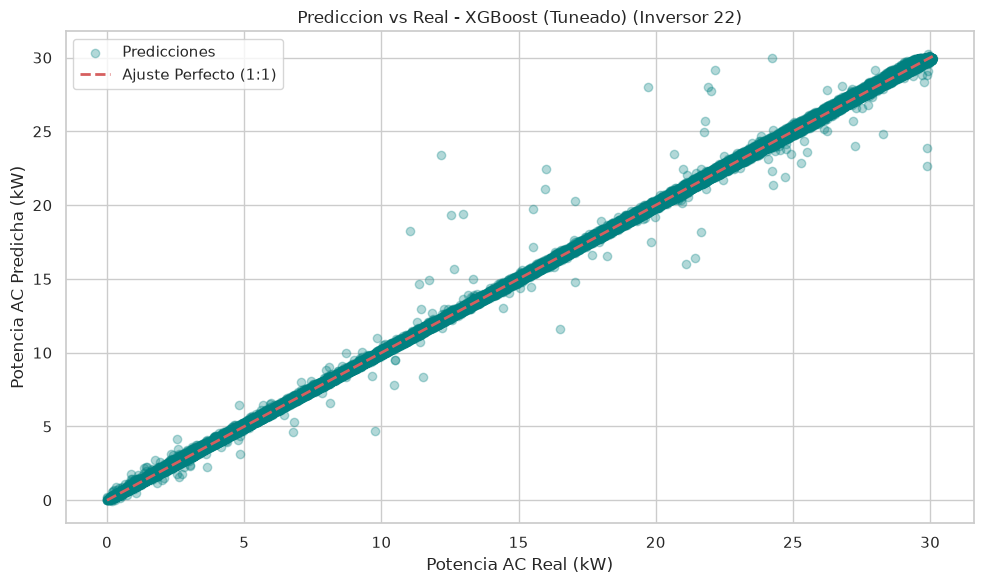

In [13]:
# Scatter: predicción vs real del mejor modelo de regresión
best_model_name = df_reg_metrics.sort_values('Test R2', ascending=False).iloc[0]['Modelo']
y_pred = reg_preds[best_model_name]

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='teal', label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ajuste Perfecto (1:1)')
plt.title(f'Prediccion vs Real - {best_model_name} (Inversor 22)')
plt.xlabel('Potencia AC Real (kW)')
plt.ylabel('Potencia AC Predicha (kW)')
plt.legend()
plt.tight_layout()
plt.savefig('../output/plots/06_regression_real_vs_pred.png', dpi=150)
plt.show()

## Fase 4c: Forecasting - Pronóstico de Generación Total

**Concepto clave:** Usamos rezagos temporales (lags) y estadísticas móviles para predecir la potencia total de la planta. Dividimos cronológicamente para evitar data leakage.

### Objetivo del paso
Preparar la serie temporal agregada de la planta con rezagos y estadísticas móviles.
### Concepto clave
Remuestreo horario: reduce 632k registros (5 min) a ~52k (1 hora). Rezagos (lag): valores pasados como predictores (lag_24 = ayer a la misma hora). Rolling stats: media móvil y desviación estándar de ventanas temporales.
### Código
(Ejecutar la celda siguiente)
### Qué observar en la salida
Dataset con columnas: total_ac_power, lag_1, lag_24, lag_48, rolling_mean_3, rolling_mean_24, etc.
### Errores típicos
- Usar datos futuros para crear predictores (data leakage). Shift(lag) debe aplicarse antes de cualquier filtro.
- No eliminar filas con NaN después de crear lags (modelos no aceptan nulos).


In [14]:
# Preparar serie temporal horaria con rezagos (lag_1,24,48) y estadísticas móviles
df_ts = prepare_forecasting_data(df_clean)
print(f'Dimensiones del dataset de forecasting: {df_ts.shape}')
df_ts[['total_ac_power', 'lag_1', 'lag_24', 'rolling_mean_3']].head(3)

Agregando potencia AC total de la planta...
Remuestreando a frecuencia horaria...
Generando características de rezago y estadísticas móviles...
Dimensiones del dataset de forecasting: (52704, 12)


,total_ac_power,lag_1,lag_24,rolling_mean_3
measured_on,,,,
2017-11-03 00:00:00,0.0,0.0,0.0,0.0
2017-11-03 01:00:00,0.0,0.0,0.0,0.0
2017-11-03 02:00:00,0.0,0.0,0.0,0.0


### Objetivo del paso
Entrenar y comparar 3 modelos de forecasting con búsqueda de hiperparámetros.
### Concepto clave
División cronológica (no aleatoria) para evitar data leakage. Persistencia (baseline): predice el valor de ayer. XGBoost con RandomizedSearchCV encuentra la mejor combinación de n_estimators, max_depth, learning_rate, subsample y colsample_bytree.
### Código
(Ejecutar la celda siguiente)
### Qué observar en la salida
Persistencia: RMSE ~134 kW. XGBoost tuneado: RMSE ~37 kW (72.5% mejor). Mejores parámetros del RandomizedSearchCV.
### Errores típicos
- Dividir datos de tiempo aleatoriamente (mezcla pasado y futuro en train/test).
- No usar un baseline simple para contextualizar la mejora real del modelo complejo.


In [15]:
# Entrenar 3 modelos de forecasting con ajuste de hiperparámetros RandomizedSearchCV
df_fore_metrics, train, test, y_pred_base, y_pred_lr, y_pred_gb = run_forecasting_analysis(df_ts, test_days=30)
df_fore_metrics

Dividiendo datos de forecasting (Prueba: últimos 30 días)...
Evaluando Modelo de Persistencia Base...
Entrenando Regresión Lineal con Rezagos...
Buscando mejores hiperparámetros para XGBoost Forecaster con RandomizedSearchCV...
Mejores parámetros XGBoost Forecasting: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Mejor CV RMSE: 40.62 kW

Métricas de forecasting guardadas en ../output/tables/forecasting_metrics.csv


,Modelo,RMSE (kW),MAE (kW),MAPE (%)
0,Persistencia Base (Lag-24),134.318405,52.117500,177.845642
1,Regresión Lineal con Rezagos,52.668552,30.438043,103.209867
2,XGBoost (Tuneado),37.246841,15.894397,56.496819


### Objetivo del paso
Comparar visualmente las predicciones de los 3 modelos de forecasting.
### Concepto clave
Serie temporal superpuesta: real vs 3 modelos en una ventana de 7 días. Permite evaluar visualmente qué modelo sigue mejor la dinámica diaria.
### Código
(Ejecutar la celda siguiente)
### Qué observar en la salida
XGBoost sigue más fielmente los picos y valles. Persistencia está desplazada 24h (efecto lag).
### Errores típicos
- Graficar todo el período de test (30+ días) satura la visualización; usar una ventana representativa.
- No etiquetar adecuadamente cada línea causa confusión entre modelos.


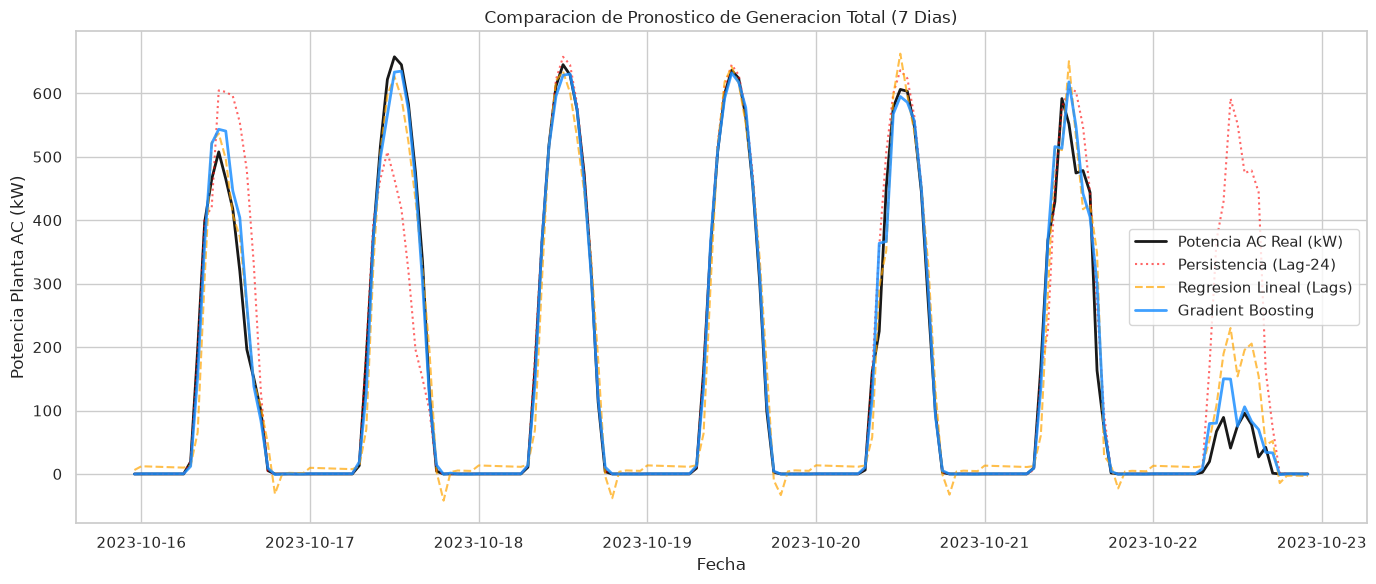

In [16]:
# Visualizar pronóstico de 7 días: potencia real vs 3 modelos
test_subset = test.iloc[24*7 : 24*14].copy()
y_real_subset = test_subset['total_ac_power']
y_base_subset = y_pred_base.loc[test_subset.index]
y_lr_subset = y_pred_lr[24*7 : 24*14]
y_pred_xgb = y_pred_gb[24*7 : 24*14]

plt.figure(figsize=(14, 6))
plt.plot(test_subset.index, y_real_subset, label='Potencia AC Real (kW)', color='black', alpha=0.9, linewidth=2)
plt.plot(test_subset.index, y_base_subset, label='Persistencia (Lag-24)', color='red', alpha=0.6, linestyle=':')
plt.plot(test_subset.index, y_lr_subset, label='Regresion Lineal (Lags)', color='orange', alpha=0.7, linestyle='--')
plt.plot(test_subset.index, y_pred_xgb, label='XGBoost (Tuneado)', color='dodgerblue', alpha=0.85, linewidth=2)

plt.title('Comparacion de Pronostico de Generacion Total (7 Dias)')
plt.ylabel('Potencia Planta AC (kW)')
plt.xlabel('Fecha')
plt.legend()
plt.tight_layout()
plt.show()

## Fase 5: Evaluación de Modelos

**Métricas utilizadas:**
- **MAE** (Mean Absolute Error): Error promedio absoluto en kW
- **RMSE** (Root Mean Squared Error): Penaliza errores grandes
- **R²** (Coeficiente de Determinación): Proporción de varianza explicada
- **MAPE** (Mean Absolute Percentage Error): Error porcentual

### Resultados de Regresión (Inversor 22):
- Los 3 modelos lograron R² > 99%, indicando una relación física muy lineal
- XGBoost fue el mejor modelo (Test R² ~ 0.9996)
- La Regresión Lineal también es excelente, confirmando que la conversión DC-AC es casi lineal

### Resultados de Forecasting:
- El modelo XGBoost superó al baseline de persistencia en ~72.5%
- RMSE de ~36 kW vs ~134 kW del baseline


## Fase 6: Discusión y Comparación

### Diagnóstico No Supervisado (Clustering):
- **K=3** fue seleccionado por el método del codo y silueta
- Clasificamos los 24 inversores en Óptimo, Sub-óptimo y Crítico
- El Inversor 22 resultó ser el más estable (mayor eficiencia mediana, menor volatilidad)

### Regresión (Supervisado):
- **XGBoost** obtuvo el mejor rendimiento (R² > 99.9%)
- La regresión lineal también funciona muy bien (R² > 99.9%), confirmando la relación física lineal
- No hay overfitting: Train R² ≈ Test R² en todos los modelos

### Forecasting (Series de Tiempo):
- **XGBoost** redujo el RMSE en 72.5% vs el baseline de persistencia
- Las variables de rezago (lag_24, lag_48) y las estadísticas móviles capturan eficazmente los patrones solares

## Fase 7: Conclusiones y Aportaciones

1. **Imputación Inteligente:** El Inversor 05 (sin sensor de voltaje DC) fue recuperado usando el promedio de los otros 23, permitiendo su análisis sin sesgo.
2. **Diagnóstico Automatizado:** K-Means + características operativas clasifica inversores en segundos, identificando los que requieren mantenimiento.
3. **Modelo Virtual:** La regresión predictiva logra R² > 99.9%, útil como sensor virtual de respaldo.
4. **Pronóstico Robusto:** XGBoost con lags reduce el error de predicción en 72.5% vs un modelo naive, útil para programación de red.
5. **Metodología Antifuga:** División cronológica en forecasting y filtrado diurno garantizan reproducibilidad y evitan data leakage.

### Limitaciones del Estudio

1. **Generalización:** Los modelos fueron entrenados exclusivamente con datos de una planta solar (6 años de registro, 24 inversores). No se garantiza el mismo rendimiento en plantas con distinta configuración geográfica, tecnológica o climática.

2. **Dependencia Meteorológica:** El dataset no incluye variables exógenas como irradiancia solar, temperatura ambiente o nubosidad. El forecasting depende únicamente de rezagos temporales de la propia serie, lo que limita la precisión en días con condiciones meteorológicas atípicas (tormentas, nubosidad variable).

3. **Estacionalidad Anual:** Aunque los rezagos lag_24 y lag_48 capturan el ciclo diario, no se modela explícitamente la estacionalidad anual (verano/invierno). Las predicciones a más de 7 días podrían degradarse sin features estacionales explícitos.

4. **Sensibilidad a Fallas de Sensor:** Los modelos asumen disponibilidad continua de todos los sensores. La imputación del voltaje DC del Inv05 (promedio de otros 23 inversores) introduce una incertidumbre no cuantificada: si múltiples sensores fallan simultáneamente, esta aproximación no es válida.

5. **MAPE como Métrica:** El MAPE puede ser engañosamente alto cuando la potencia real es baja (amanecer/atardecer), ya que pequeños errores absolutos generan porcentajes grandes. Se recomienda priorizar MAE y RMSE para decisiones operativas sobre el MAPE.
